# Scalability EDA — one-shot vs two-stage decomposition

Does splitting **flow** (Stage 1) from **packing** (Stage 2) scale better than
solving them jointly, and does the answer differ between the pure-ASP (`naive`)
and CASP (`clingcon`) backends?

| Solver | Family | Backend |
|--------|--------|---------|
| `naive_oneshot` | one-shot | naive |
| `clingcon_oneshot` | one-shot | clingcon |
| `naive_twostage` | two-stage | naive |
| `clingcon_twostage` | two-stage | clingcon |

Two-stage runs use `weight=0, hetero_on=0, concentrated_on=0` so Stage 1
minimises pure transport cost and Stage 2 minimises used trips — the closest
analogue to the one-shot objective.

**Time-limit semantics matter:** one-shot gets `time_limit` for a single solve;
two-stage gets `time_limit` *per stage*, so its wall time can reach ~2×.

**Cost comparability:** the `cost` column is apples-to-apples (transport cost)
across all four — for two-stage it equals `s1_cost`. `s2_cost` (used-trip count)
is a different objective and is **not** compared to one-shot cost.

**Sizes covered:** `paper` (5 loc), `small` (6 loc), `medium` (8 loc),
3 reps each (loaded from the raw CSVs and aggregated here).

In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

# Resolve the results directory whether the notebook is run from results/,
# the experiment dir, or new_code/.
def _find_results(target):
    here = os.getcwd()
    for cand in (".", target,
                 os.path.join("src/multibatch/experiments", target)):
        if os.path.isdir(cand) and glob.glob(os.path.join(cand, "*.csv")):
            return os.path.abspath(cand)
    return os.path.abspath(".")

# Consistent solver colours / order across the notebook.
def style_for(names):
    pal = sns.color_palette("tab10", n_colors=max(len(names), 3))
    return {n: pal[i] for i, n in enumerate(names)}

def relative_cost(df, group_cols, cost_col="cost", out="rel_cost"):
    """cost / best (min) cost on the same instance group. 1.0 == best found."""
    best = df.groupby(group_cols)[cost_col].transform("min")
    df = df.copy()
    df[out] = df[cost_col] / best
    return df

In [2]:
RESULTS = _find_results("scalability/results")
print("Loading from:", RESULTS)

frames = []
for size in ("paper", "small", "medium"):
    p = os.path.join(RESULTS, f"scalability_raw_{size}.csv")
    if os.path.exists(p):
        frames.append(pd.read_csv(p))
raw = pd.concat(frames, ignore_index=True)

SIZE_ORDER = ["paper", "small", "medium"]
raw["instance_size"] = pd.Categorical(raw.instance_size, SIZE_ORDER, ordered=True)
SOLVER_ORDER = ["naive_oneshot", "clingcon_oneshot", "naive_twostage", "clingcon_twostage"]
COLORS = style_for(SOLVER_ORDER)
print("rows:", len(raw), "| sizes:", raw.instance_size.value_counts().to_dict())

Loading from: /Users/racqueldennison/Documents/Masters/realdeal_masters/combined_encodings/new_code/src/multibatch/experiments/scalability/results
rows: 96 | sizes: {'small': 60, 'medium': 24, 'paper': 12}


## 1. Data overview & sanity checks

In [3]:
print("statuses:", raw.status.value_counts().to_dict())
print("solvers:", sorted(raw.solver.unique()))
print()
print("Instance properties by size:")
display(raw.groupby("instance_size", observed=True)[
    ["n_locations", "n_parts", "n_routes", "n_transports",
     "density", "capacity_tightness"]].mean().round(2))

print("Runs per (size, solver):")
display(raw.pivot_table(index="solver", columns="instance_size",
                        values="run", aggfunc="size", observed=True)
           .reindex(SOLVER_ORDER))

statuses: {'OK': 96}
solvers: ['clingcon_oneshot', 'clingcon_twostage', 'naive_oneshot', 'naive_twostage']

Instance properties by size:


,n_locations,n_parts,n_routes,n_transports,density,capacity_tightness
instance_size,,,,,,
paper,5.0,2.0,11.0,2.0,0.28,0.98
small,6.0,2.0,18.8,2.0,0.31,1.47
medium,8.0,3.0,40.5,2.0,0.36,2.48


Runs per (size, solver):


instance_size,paper,small,medium
solver,,,
naive_oneshot,3,15,6
clingcon_oneshot,3,15,6
naive_twostage,3,15,6
clingcon_twostage,3,15,6


In [4]:
# Single tidy aggregate reused throughout.
def agg(df):
    return (df.groupby(["instance_size", "solver"], observed=True)
              .agg(n=("run", "size"),
                   wall=("wall_time", "mean"),
                   total=("total_time", "mean"),
                   ground=("ground_time", "mean"),
                   solve=("solve_time", "mean"),
                   s1=("s1_time", "mean"),
                   s2=("s2_time", "mean"),
                   atoms=("atoms", "mean"),
                   s1_atoms=("s1_atoms", "mean"),
                   s2_atoms=("s2_atoms", "mean"),
                   cost=("cost", "mean"),
                   opt=("optimum", "mean"),
                   sat=("satisfiable", "mean"))
              .round(2))
A = agg(raw)
A

n    wall   total  ground   solve      s1      s2       atoms  s1_atoms  s2_atoms       cost  opt  sat
instance_size solver                                                                                                                    
paper         clingcon_oneshot    3   39.86   39.85    0.01   39.85     NaN     NaN     1674.00       NaN       NaN    7490.00  1.0  1.0
              clingcon_twostage   3    5.30    5.29    0.00    5.29    5.28    0.00     1901.00    1225.0    676.00    3458.00  1.0  1.0
              naive_oneshot       3  600.39  600.35    0.34  600.01     NaN     NaN   222789.00       NaN       NaN    7602.00  0.0  1.0
              naive_twostage      3   12.47   12.47    0.01   12.46   12.46    0.01     2724.00    1937.0    787.00    3458.00  1.0  1.0
small         clingcon_oneshot   15  113.83  113.82    0.01  113.80     NaN     NaN     3234.00       NaN       NaN    9880.00  1.0  1.0
              clingcon_twostage  15  357.92  357.90    0.01  357.88  147.05  210.85     2925.40    2027.8    897.60    3903.80  0.6  1.0
              naive_oneshot      15  601.10  600.89    0.86  600.03     NaN     NaN   741570.20       NaN       NaN   10887.27  0.0  1.0
              naive_twostage     15  597.54  597.52    0.03  597.49  475.41  122.11     5148.00    3650.2   1497.80    3991.00  0.4  1.0
medium        clingcon_oneshot    6  600.08  600.06    0.02  600.04     NaN     NaN    10663.50       NaN       NaN  213458.00  0.0  1.0
              clingcon_twostage   6  900.20  900.17    0.02  900.16  600.05  300.12     5909.00    4526.0   1383.00    6151.83  0.0  1.0
              naive_oneshot       6  603.17  602.80    2.78  600.02     NaN     NaN  2994399.50       NaN       NaN   11235.33  0.0  1.0
              naive_twostage      6  900.25  900.23    0.04  900.19  600.05  300.18    11269.17    9187.0   2082.17    7985.33  0.0  1.0

## 2. Time scaling across sizes

`wall_time` is the fair clock comparison (it brackets both stages for
two-stage). Watch how the one-shot solvers saturate their budget while the
two-stage variants often finish early at small scales. Log scale.

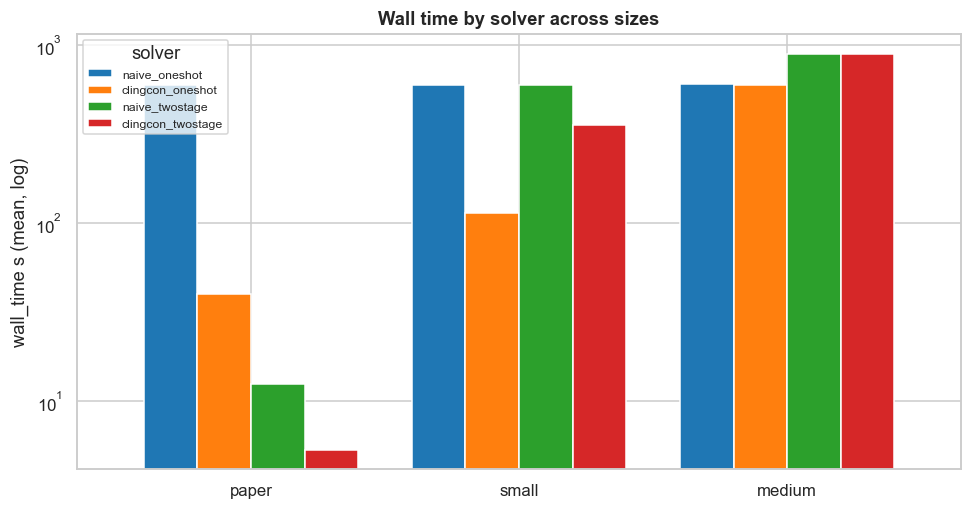

In [5]:
piv = raw.pivot_table(index="instance_size", columns="solver",
                      values="wall_time", aggfunc="mean", observed=True)
piv = piv.reindex(columns=[s for s in SOLVER_ORDER if s in piv.columns])
ax = piv.plot.bar(figsize=(9, 4.8), width=0.8,
                  color=[COLORS[s] for s in piv.columns])
ax.set_yscale("log"); ax.set_ylabel("wall_time s (mean, log)")
ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
ax.set_title("Wall time by solver across sizes")
ax.legend(fontsize=8, title="solver"); plt.tight_layout(); plt.show()

## 3. Atom growth — the ASP scaling signal

Ground-program size is the structural reason naive struggles. Compare one-shot
vs two-stage *and* naive vs clingcon. For two-stage we also split `s1_atoms` /
`s2_atoms` to show that decomposition keeps **each** stage small. Log scale.

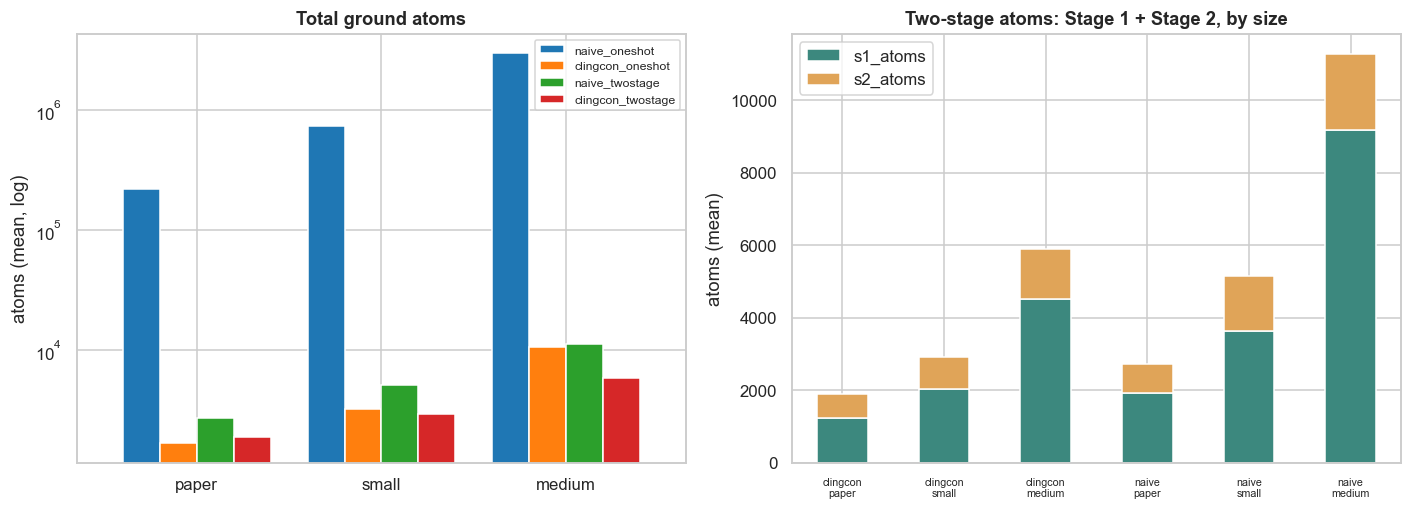

medium atoms: naive_oneshot=2,994,400 vs naive_twostage=11,269 (266x smaller)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
# (a) total atoms by solver across sizes
piv = raw.pivot_table(index="instance_size", columns="solver", values="atoms",
                      aggfunc="mean", observed=True)
piv = piv.reindex(columns=[s for s in SOLVER_ORDER if s in piv.columns])
piv.plot.bar(ax=axes[0], width=0.8, color=[COLORS[s] for s in piv.columns])
axes[0].set_yscale("log"); axes[0].set_ylabel("atoms (mean, log)")
axes[0].set_title("Total ground atoms"); axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0); axes[0].legend(fontsize=8)

# (b) two-stage stage split, per size (linear so the stack is additive-valid)
ts = raw[raw.encoding_family == "two-stage"]
g = (ts.groupby(["solver", "instance_size"], observed=True)[["s1_atoms", "s2_atoms"]]
       .mean())
g.index = [f"{s.replace('_twostage','')}\n{sz}" for s, sz in g.index]
g.plot.bar(ax=axes[1], stacked=True, color=["#3c887e", "#e0a458"])
axes[1].set_ylabel("atoms (mean)")
axes[1].set_title("Two-stage atoms: Stage 1 + Stage 2, by size")
axes[1].set_xlabel(""); axes[1].tick_params(axis="x", rotation=0, labelsize=7)
plt.tight_layout(); plt.show()

mrow = A.xs("medium", level="instance_size")
print(f"medium atoms: naive_oneshot={mrow.loc['naive_oneshot','atoms']:,.0f} "
      f"vs naive_twostage={mrow.loc['naive_twostage','atoms']:,.0f} "
      f"({mrow.loc['naive_oneshot','atoms']/mrow.loc['naive_twostage','atoms']:.0f}x smaller)")

## 4. Where the time is paid — stages & ground vs solve

For two-stage, `s1_time` (flow optimisation) vs `s2_time` (packing) locates the
bottleneck; for one-shot, `ground_time` vs `solve_time` does the same.

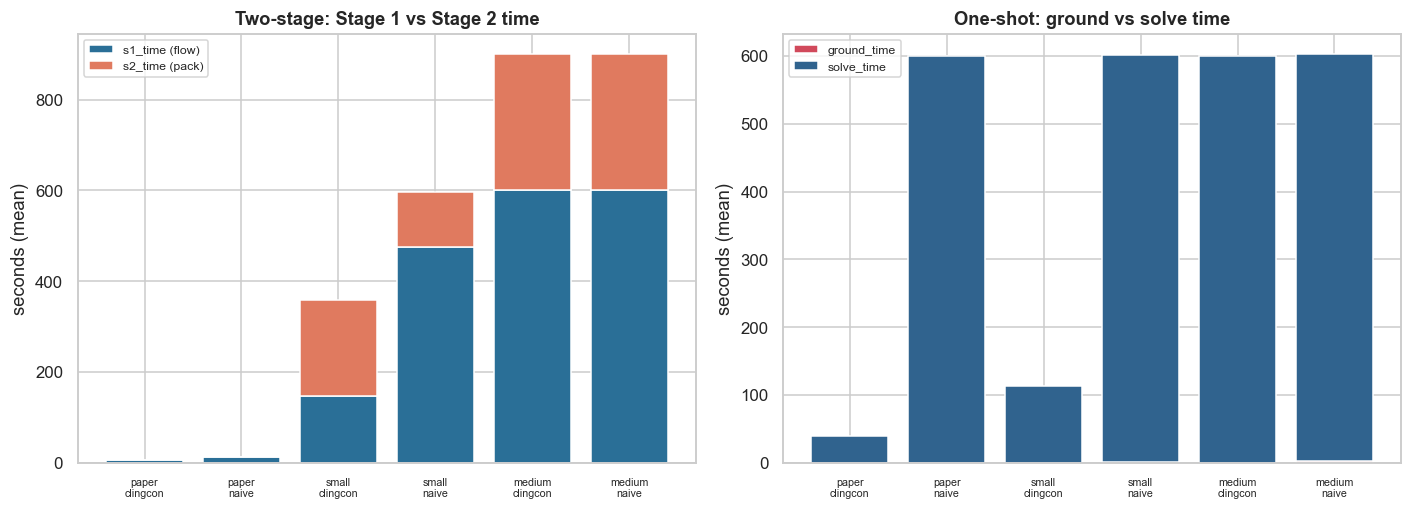

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# (a) two-stage: s1 vs s2 across sizes
ts = raw[raw.encoding_family == "two-stage"]
g = ts.groupby(["instance_size", "solver"], observed=True)[["s1_time", "s2_time"]].mean()
g = g.reset_index()
labels = [f"{r.instance_size}\n{r.solver.replace('_twostage','')}" for r in g.itertuples()]
x = np.arange(len(g))
axes[0].bar(x, g.s1_time, label="s1_time (flow)", color="#2a6f97")
axes[0].bar(x, g.s2_time, bottom=g.s1_time, label="s2_time (pack)", color="#e07a5f")
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, fontsize=7)
axes[0].set_ylabel("seconds (mean)"); axes[0].set_title("Two-stage: Stage 1 vs Stage 2 time")
axes[0].legend(fontsize=8)

# (b) one-shot: ground vs solve across sizes
os_ = raw[raw.encoding_family == "one-shot"]
g2 = os_.groupby(["instance_size", "solver"], observed=True)[["ground_time", "solve_time"]].mean().reset_index()
labels2 = [f"{r.instance_size}\n{r.solver.replace('_oneshot','')}" for r in g2.itertuples()]
x2 = np.arange(len(g2))
axes[1].bar(x2, g2.ground_time, label="ground_time", color="#d1495b")
axes[1].bar(x2, g2.solve_time, bottom=g2.ground_time, label="solve_time", color="#30638e")
axes[1].set_xticks(x2); axes[1].set_xticklabels(labels2, fontsize=7)
axes[1].set_ylabel("seconds (mean)"); axes[1].set_title("One-shot: ground vs solve time")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. Solution quality — optimum rate & relative cost

`cost` is comparable across solvers, but instance scales differ across seeds, so
we again use **relative cost** = cost ÷ best cost found on that instance.
Two-stage decomposition is expected to reach lower transport cost faster because
each subproblem is small enough to optimise within budget.

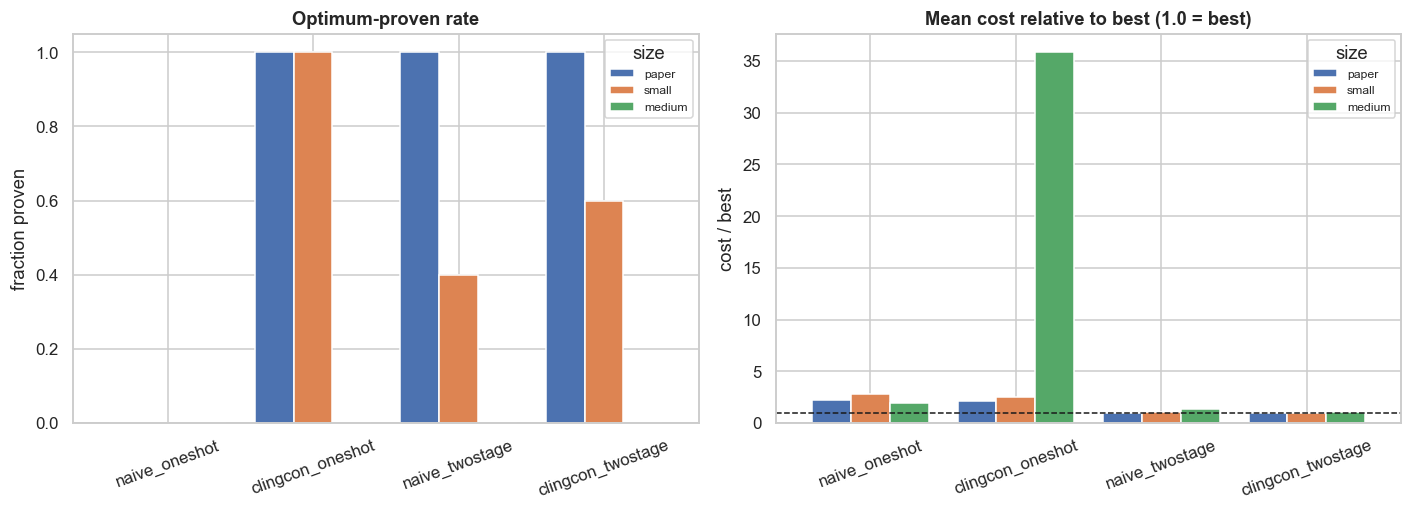

instance_size,paper,small,medium
solver,,,
naive_oneshot,2.20,2.78,1.91
clingcon_oneshot,2.17,2.55,35.84
naive_twostage,1.00,1.02,1.32
clingcon_twostage,1.00,1.00,1.05


In [8]:
rc = relative_cost(raw, ["instance_size", "instance"])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

opt = rc.pivot_table(index="solver", columns="instance_size", values="optimum",
                     aggfunc="mean", observed=True).reindex(SOLVER_ORDER)
opt.plot.bar(ax=axes[0], width=0.8)
axes[0].set_title("Optimum-proven rate"); axes[0].set_ylabel("fraction proven")
axes[0].set_xlabel(""); axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(title="size", fontsize=8)

mrc = rc.pivot_table(index="solver", columns="instance_size", values="rel_cost",
                     aggfunc="mean", observed=True).reindex(SOLVER_ORDER)
mrc.plot.bar(ax=axes[1], width=0.8)
axes[1].axhline(1.0, color="k", ls="--", lw=1)
axes[1].set_title("Mean cost relative to best (1.0 = best)")
axes[1].set_ylabel("cost / best"); axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20); axes[1].legend(title="size", fontsize=8)
plt.tight_layout(); plt.show()
mrc.round(2)

## 6. Decomposition benefit — one-shot vs two-stage, per backend

The core question, isolated: for each backend, what does splitting the problem
buy you in **wall time** and in **cost**?

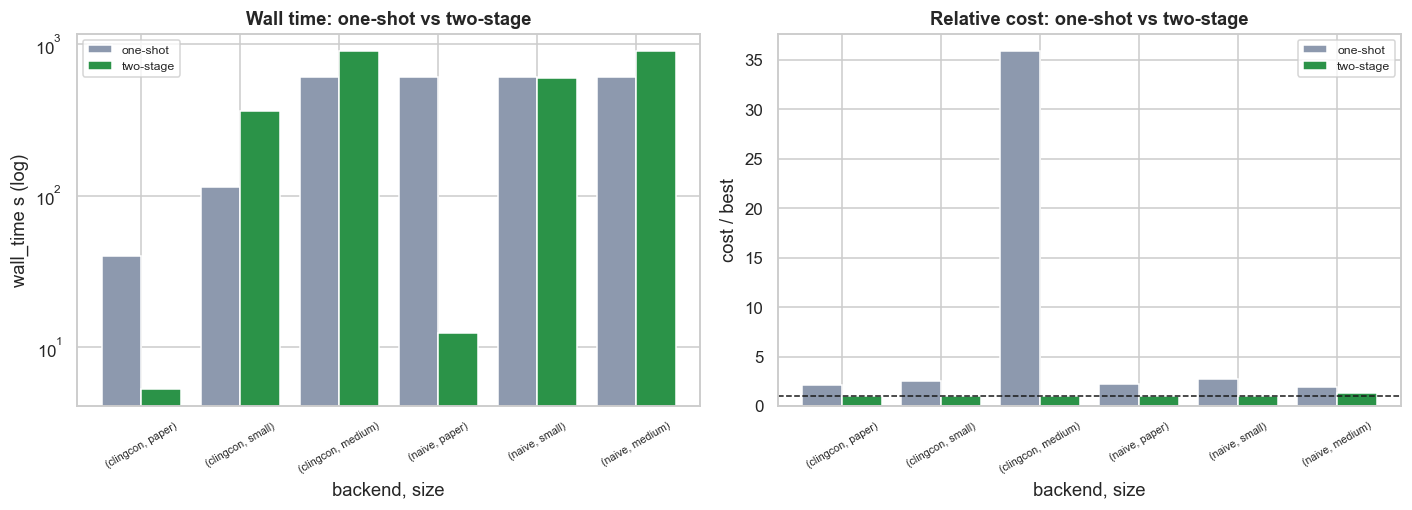

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# wall time: oneshot vs twostage, grouped by backend, faceted by size
wt = raw.groupby(["backend", "encoding_family", "instance_size"], observed=True)["wall_time"].mean().reset_index()
piv = wt.pivot_table(index=["backend", "instance_size"], columns="encoding_family", values="wall_time", observed=True)
piv = piv[["one-shot", "two-stage"]]
piv.plot.bar(ax=axes[0], width=0.8, color=["#8d99ae", "#2b9348"])
axes[0].set_yscale("log"); axes[0].set_ylabel("wall_time s (log)")
axes[0].set_title("Wall time: one-shot vs two-stage"); axes[0].set_xlabel("backend, size")
axes[0].tick_params(axis="x", rotation=30, labelsize=7); axes[0].legend(fontsize=8)

# relative cost: oneshot vs twostage
ct = rc.groupby(["backend", "encoding_family", "instance_size"], observed=True)["rel_cost"].mean().reset_index()
pivc = ct.pivot_table(index=["backend", "instance_size"], columns="encoding_family", values="rel_cost", observed=True)
pivc = pivc[["one-shot", "two-stage"]]
pivc.plot.bar(ax=axes[1], width=0.8, color=["#8d99ae", "#2b9348"])
axes[1].axhline(1.0, color="k", ls="--", lw=1)
axes[1].set_ylabel("cost / best"); axes[1].set_title("Relative cost: one-shot vs two-stage")
axes[1].set_xlabel("backend, size"); axes[1].tick_params(axis="x", rotation=30, labelsize=7)
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 7. Findings (scalability)

1. **Decomposition removes the grounding wall.** `naive_twostage` grounds
   ~10²–10³× fewer atoms than `naive_oneshot` (millions → thousands on medium),
   because neither stage ever instantiates the full joint flow-×-packing space.
2. **Two-stage finds better transport cost, often far faster.** At `paper`/
   `small` both two-stage variants reach near-best cost in seconds while the
   one-shot solvers burn their full budget; `naive_oneshot` never proves
   optimality at any size here.
3. **Backend × decomposition interaction:** `clingcon` already grounds compactly,
   so its one-shot version is competitive at small scale and even proves
   optimality on `paper`/`small`; the *naive* backend is the one that depends on
   decomposition to remain viable.
4. **Stage balance shifts with size:** Stage 1 (flow) dominates two-stage time
   at small scale, but Stage 2 (packing) grows as instances get denser — see the
   `s1_time`/`s2_time` split.
5. **The frontier:** by `medium`, every one-shot solver and even the two-stage
   solvers hit their per-stage time limits, so `medium` is the current scaling
   edge for this configuration set.

Caveat: two-stage wall time can be ~2× one-shot by construction (per-stage
budget); comparisons above use `wall_time` and relative cost to stay fair.